# Example 2: DC Engine Simulation

This example models the behaviour of real hardware, the **Maxon RE 40** motor. The simulation is based on the motor's physical characteristics and is intended to reproduce its expected behaviour under defined operating conditions. For an input voltage of 48 V and zero load torque, the model reaches a steady-state speed of 1,720 rpm, which is consistent with the expected motor performance. The simulated response dynamics also agrees well with the motor's catalogue time constant of 4.15 ms.

## Imports

The required packages are: `Akson` for the core functionality, `torch` for defining state-space system matrices, and `matplotlib` for plotting.

In [1]:
import akson
import torch
import matplotlib.pyplot as plt

## Modeling the DC Engine Dynamics

The Maxon RE 40 218013 was selected for modelling. Motor parameters were obtained from the [manufacturer's datasheet](https://www.maxongroup.co.uk/maxon/view/product/motor/dcmotor/re/re40/218013). The mathematical formulation follows "Podstawy Automatyki" by Malinowski and Tatjewski. DC motor parameters:

In [2]:
b = 5.365e-6
k_m = 0.266
J = 1.2e-5
k_e = 0.266
R = 24.4
L = 6.41e-3

LTI state-space system matrices:

In [3]:
A = torch.tensor([[-b/J, k_m/J], [-k_e/L, -R/L]]).to(torch.float64)
B = torch.tensor([[0.], [1./L]]).to(torch.float64)
C = torch.tensor([[1., 0.]]).to(torch.float64)
D = torch.tensor([[0.]]).to(torch.float64)

State-space system:

In [4]:
system_dynamics = akson.StateSpaceDynamics.from_linear(A, B, C, D)
system_dynamics

## State-Space System Definition

`StateSpaceSystem` combines `StateSpaceDynamics` and plant state. The state is mutable and reflects the cumulative effect of past inputs on the system. State-space system definition:

In [5]:
system = akson.StateSpaceSystem(system_dynamics)

## Simulation

Input signal function definition:

In [6]:
def u(t):
    if t < 0.025:
        return torch.tensor([48.])
    elif t < 0.05:
        return torch.tensor([24.])
    elif t < 0.075:
        return torch.tensor([48.])
    else:
        return torch.tensor([0.])

The plant input is plotted below:

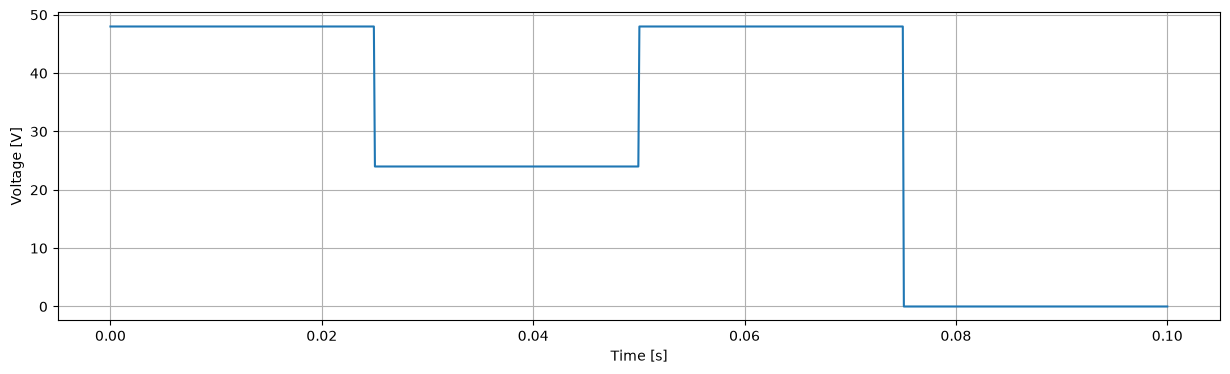

In [7]:
plt.figure(figsize=(15, 4))
t = torch.linspace(0., 0.1, 1000)
plt.plot(t, [u(c_t) for c_t in t])
plt.grid()
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.show()

Open-loop DC engine simulation:

In [8]:
t1, x1, y1 = system.simulate(u, duration=0.05)

/home/antoni/Documents/PRACA/akson/src/akson/state_space_system.py:926: RuntimeWarning: RKF45: 20 consecutive rejected steps at x=0.000e0, step=1.684e-5; problem may be stiff
  t_sub, x_sub = solver.solve(traced_ode_fn, t_span, y0)


The plant output is plotted below:

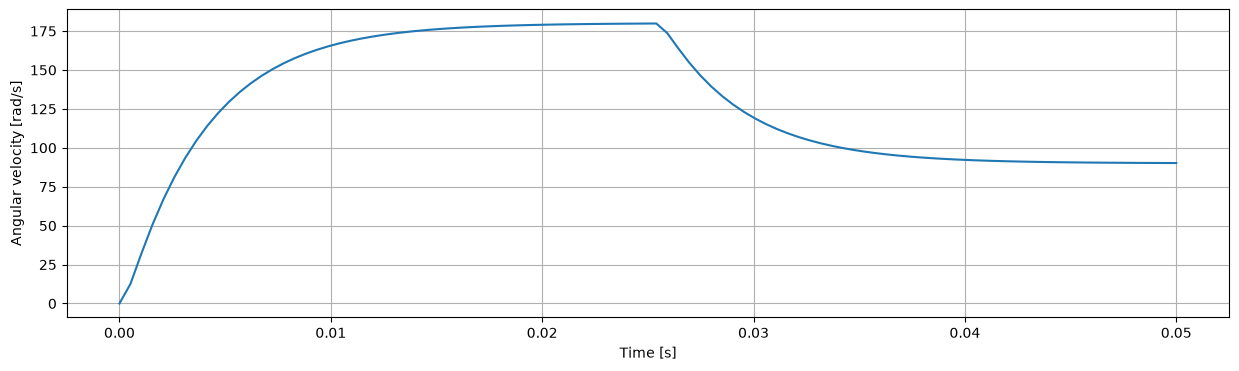

In [9]:
plt.figure(figsize=(15, 4))
plt.plot(t1, y1[:, 0])
plt.grid()
plt.xlabel('Time [s]')
plt.ylabel('Angular velocity [rad/s]')
plt.show()

The simulation is continued:

In [10]:
t2, x2, y2 = system.simulate(u, duration=0.05)

The plant output is plotted:

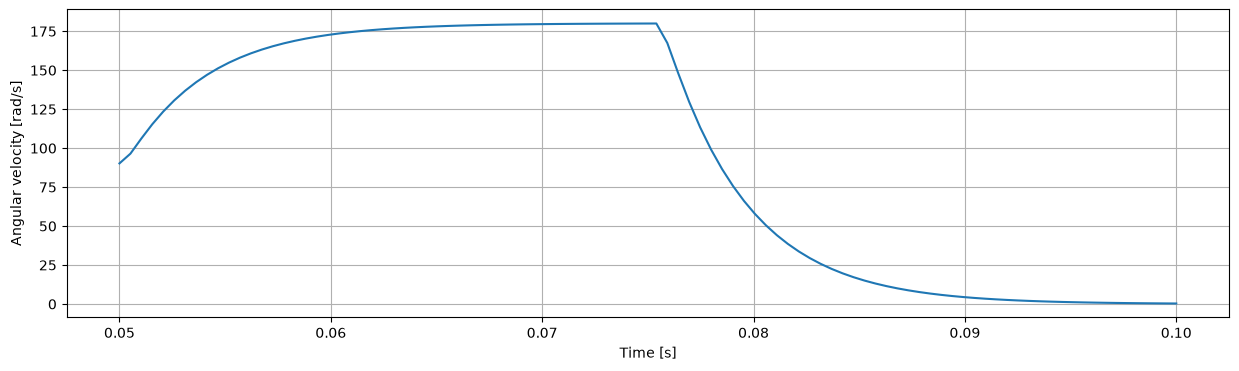

In [11]:
plt.figure(figsize=(15, 4))
plt.plot(t2, y2[:, 0])
plt.grid()
plt.xlabel('Time [s]')
plt.ylabel('Angular velocity [rad/s]')
plt.show()

The complete simulation (executed in two stages) is plotted below:

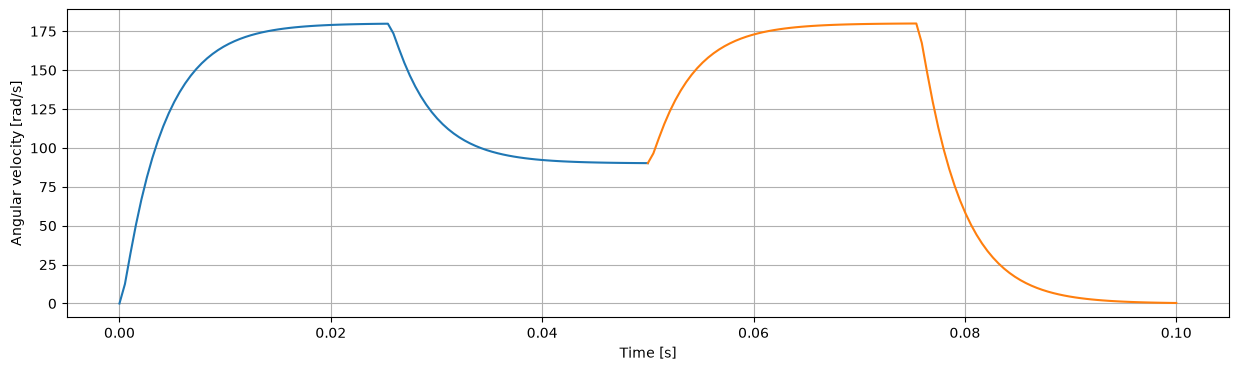

In [12]:
plt.figure(figsize=(15, 4))
plt.plot(t1, y1[:, 0])
plt.plot(t2, y2[:, 0])
plt.grid()
plt.xlabel('Time [s]')
plt.ylabel('Angular velocity [rad/s]')
plt.show()